# Современные методы анализа данных и машинного обучения, БИ

## НИУ ВШЭ, 2025-26 учебный год

## Групповой проект №4. Statistics in Data Analysis


## Описание задания

Практика A/B-тестирования, формирования и проверки статистических гипотез лежит в основе принятия решений в любой современной компании, работающей с данными. Умение корректно провести эксперимент, проинтерпретировать результаты и сформулировать выводы непосредственно влияет на возможность роста продукта, сокращение издержек и уменьшение рисков.


Данный групповой проект состоит из **двух частей**:

1. **A/B-тестирование**: анализ результатов эксперимента, которые зафиксированы в датасете `data_ab.csv`, — проверка наличия статистически и практически значимых различий между наблюдениями в контрольной и экспериментальной группах.
2. **Проверка гипотез на выбранном датасете**: выбор одного или нескольких датасетов с сайта [UCI Machine Learning Repository](https://archive.ics.uci.edu/) либо же получение соответствующих датасетов путем парсинга/работы с API; осуществление этапа первичного анализа данных (EDA); определение не менее трёх содержательных гипотез **на основе проделанного EDA**; их проверка с помощью различнных статистических тестов.


### Постановка задачи

#### Часть 1. A/B-тест

Для выполнения первой части группового проекта вам предоставляется датасет с результатами проведения некоторого A/B-тестирования в компании из сферы образования.


Датасет состоит из пяти столбцов:

* `user_id` — уникальный идентификатор пользователя;

* `timestamp` — время посещения пользователем страницы;

* `group` — группа эксперимента, к которой был случайно отнесён пользователь:

  *   `control` — контрольная группа,
  *   `treatment` — экспериментальная группа;

* `landing_page` — версия лендинга, которую увидел пользователь:

  *   `old_page` — старая версия страницы,
  *   `new_page` — новая версия страницы;

* `converted` — бинарный признак, показывающий, совершил ли пользователь целевое действие (целевым действием является регистрация на курс).








По замыслу A/B-теста контрольной группе (`control`) должна была показываться старая версия лендинга — `old_page`; экспериментальной группе (`treatment`) должна была показываться новая версия лендинга — `new_page`.

Вам следует:
- понять структуру данных, провести EDA и выбрать метрику, с которой будете работать;
- проверить корректность проведения тестирования (посмотреть на однородность групп; задуматься об A/A-тесте; не забыть, что в нашем распоряжении есть еще и временные метки);
- сформулировать нулевую и альтернативную гипотезы на основании выбранной метрики;
- выбрать и обосновать статистический тест;
- решить, нужно ли устаналивать значения каких-либо параметров до начала анализа тестирования;
- оценить разницу в результатах и сделать выводы о практической значимости эксперимента;
- провести дополнительный анализ при необходимости (например, с помощью [bootstrap](https://habr.com/ru/companies/X5Tech/articles/679842/)  или через анализ чувствительности);
- сформулировать рекомендации и бизнес-инсайты по результатам эксперимента.

**Важно**: это лишь возможные шаги для вашего исследования, и воспринимать их следует как подсказки. Ваша центральная задача в любом случае представлена в общем виде — осуществить качественный и полный анализ результатов проведенного A/B-тестирования.



#### Понять структуру данных, провести EDA и выбрать метрику, с которой будете работать;

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('data_ab.csv')

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   user_id       294478 non-null  int64
 1   timestamp     294478 non-null  str  
 2   group         294478 non-null  str  
 3   landing_page  294478 non-null  str  
 4   converted     294478 non-null  int64
dtypes: int64(2), str(3)
memory usage: 11.2 MB


294478 строчек, и 5 столбцов, нет пропусков. Проверим есть ли дубликаты

In [5]:
data = data.drop_duplicates()
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   user_id       294478 non-null  int64
 1   timestamp     294478 non-null  str  
 2   group         294478 non-null  str  
 3   landing_page  294478 non-null  str  
 4   converted     294478 non-null  int64
dtypes: int64(2), str(3)
memory usage: 11.2 MB


Дубликатов нет

In [6]:
data.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2025-01-21 22:11:48.556739,control,old_page,0
1,804228,2025-01-12 08:01:45.159739,control,old_page,0
2,661590,2025-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2025-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2025-01-21 01:52:26.210827,control,old_page,1


In [7]:
cr1 = data.groupby(['group', 'landing_page'])['converted'].sum()/data.groupby(['group', 'landing_page'])['converted'].count()

cr1

group      landing_page
control    new_page        0.121369
           old_page        0.120386
treatment  new_page        0.118807
           old_page        0.127226
Name: converted, dtype: float64

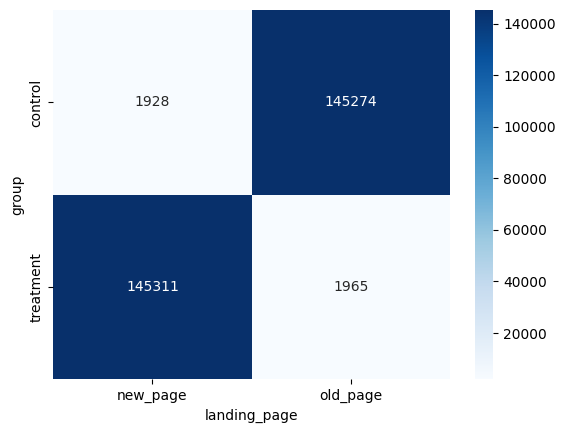

In [8]:
cross = pd.crosstab(data['group'], data['landing_page']) # https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html

sns.heatmap(cross, annot=True, fmt='d', cmap='Blues')
plt.show()

In [9]:
data['date'] = pd.to_datetime(data['timestamp']).dt.date
data

,user_id,timestamp,group,landing_page,converted,date
0,851104,2025-01-21 22:11:48.556739,control,old_page,0,2025-01-21
1,804228,2025-01-12 08:01:45.159739,control,old_page,0,2025-01-12
2,661590,2025-01-11 16:55:06.154213,treatment,new_page,0,2025-01-11
3,853541,2025-01-08 18:28:03.143765,treatment,new_page,0,2025-01-08
4,864975,2025-01-21 01:52:26.210827,control,old_page,1,2025-01-21
...,...,...,...,...,...,...
294473,751197,2025-01-03 22:28:38.630509,control,old_page,0,2025-01-03
294474,945152,2025-01-12 00:51:57.078372,control,old_page,0,2025-01-12
294475,734608,2025-01-22 11:45:03.439544,control,old_page,0,2025-01-22
294476,697314,2025-01-15 01:20:28.957438,control,old_page,0,2025-01-15


C:\Users\tim7m\AppData\Local\Temp\ipykernel_783952\3038049399.py:13: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  axes.plot(df['date'], df['converted'], label=label)


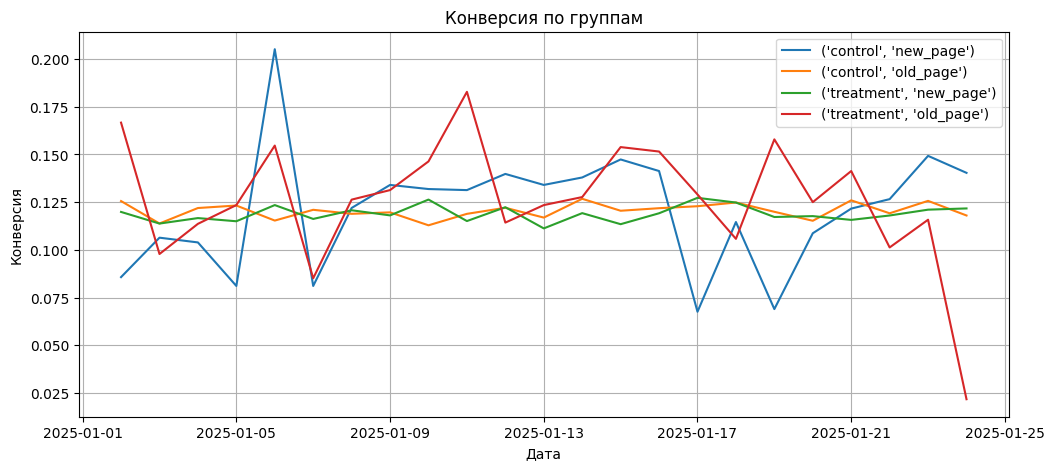

In [10]:
daily_conv = data.groupby(['date', 'group', 'landing_page'])['converted'].mean().reset_index()

# date	group	landing_page	converted
# 0	2025-01-02	control	new_page	0.085714
# 1	2025-01-02	control	old_page	0.125568
# 2	2025-01-02	treatment	new_page	0.119874
# 3	2025-01-02	treatment	old_page	0.166667
# 4	2025-01-03	control	new_page	0.106383

fig, axes = plt.subplots(figsize=(12, 5))

for label, df in daily_conv.groupby(['group', 'landing_page']):
    axes.plot(df['date'], df['converted'], label=label)



axes.set_title('Конверсия по группам')
axes.set_xlabel('Дата')
axes.set_ylabel('Конверсия')
axes.legend()
plt.grid(True)
plt.show()


Графики control + old_page и treatment + new_page остаются примерно на одном уровне, аномальный взлетов или падений не выявлено

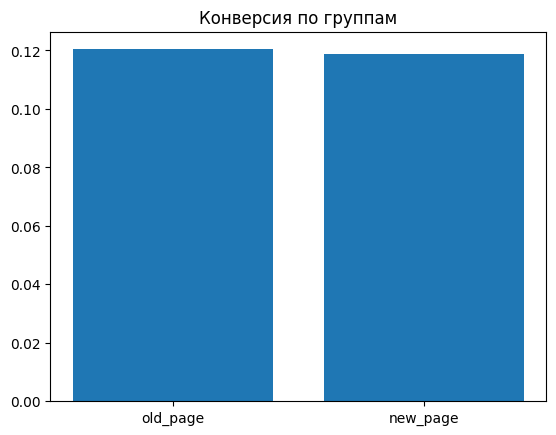

(np.float64(0.1203863045004612), np.float64(0.11880724790277405))

In [11]:
crs = data.groupby(['group', 'landing_page'])['converted'].mean().reset_index()
cr_old_page = crs[(crs['landing_page'] == 'old_page') & (crs['group'] == 'control')]
cr_new_page = crs[(crs['landing_page'] == 'new_page') & (crs['group'] == 'treatment')]

plt.bar(['old_page', 'new_page'], [cr_old_page['converted'].values[0], cr_new_page['converted'].values[0]])
plt.title('Конверсия по группам')
plt.show()
cr_old_page['converted'].values[0], cr_new_page['converted'].values[0]

![picture](test_guide.png)

Тип данных - Categorical (0/1 converted), Задача - Test proportions

Конверсия новой страницы даже уменьшилась, но нужно проверить статзначимость этого изменения

In [12]:
from statsmodels.stats.proportion import proportions_ztest

results = []

for i in range(100):
    df_aa = data[(data['group'] == 'control') & (data['landing_page'] == 'old_page')]

    df_aa['aa_group'] = np.random.choice(['A1', 'A2'], size=len(df_aa))

    a1 = df_aa[df_aa['aa_group'] == 'A1']['converted']
    a2 = df_aa[df_aa['aa_group'] == 'A2']['converted']


    count = [a1.sum(), a2.sum()]
    nobs = [len(a1), len(a2)]

    stat, pvalue = proportions_ztest(count, nobs)

    results.append(pvalue)

np.mean(np.array(results))

np.float64(0.4580482265001739)

H0: конверсии в группах одинаковые
H1: конверсии различаются в любую сторону (двусторонняя)

После 100 запусков АА тестов с рандомным разбиением данных **control** + **old_page** средний p-value примерно равен 0.5 => Существенных отклонений от случайного поведения не обнаружено

In [13]:
from statsmodels.stats.proportion import proportions_ztest

results = []

for i in range(100):
    df_aa = data[(data['group'] == 'treatment') & (data['landing_page'] == 'new_page')]

    df_aa['aa_group'] = np.random.choice(['A1', 'A2'], size=len(df_aa))

    a1 = df_aa[df_aa['aa_group'] == 'A1']['converted']
    a2 = df_aa[df_aa['aa_group'] == 'A2']['converted']


    count = [a1.sum(), a2.sum()]
    nobs = [len(a1), len(a2)]

    stat, pvalue = proportions_ztest(count, nobs)

    results.append(pvalue)

np.mean(np.array(results))

np.float64(0.4835961794143231)

H0: конверсии в группах одинаковые
H1: конверсии различаются в любую сторону (двусторонняя)

После 100 запусков АА тестов с рандомным разбиением данных **treament** + **new_page** средний p-value примерно равен 0.5 => Существенных отклонений от случайного поведения не обнаружено

In [14]:
# AB тест для проверки корректности данных

from statsmodels.stats.proportion import proportions_ztest

control = data[(data['group'] == 'control') & (data['landing_page'] == 'old_page')]['converted']
treatment = data[(data['group'] == 'treatment') & (data['landing_page'] == 'new_page')]['converted']

count = [control.sum(), treatment.sum()] # колво конверсий в каждой группе
nobs = [len(control), len(treatment)] # колво наблюдений в каждой группе

stat, pvalue = proportions_ztest(count, nobs, alternative='two-sided')

f'p-value: {round(pvalue,4)}'

'p-value: 0.1897'

H0: конверсии в группах control и treatment равны
H1: конверсии в группах control и treatment не равны (не рассматриваем какая из них лучше или хуже)

Параметры теста alpha = 0.05 (default), power = 0.8 (default), альтернативная гипотеза - двустронняя: хотим заметить любую разницу выборок - меньше или больше

p-value = 0.1897 => мы не отвегаем H0, так как p-value > 0.05. Cтатистически значимых различий между группами 
не обнаружено.

In [25]:
from statsmodels.stats.proportion import proportions_chisquare

res = proportions_chisquare(count, nobs)

round(res[1], 4)

np.float64(0.1897)

Результат chisquare теста получился таким же, как у z_test. 